# Feature Extraction

This notebook serves to experiment and produce feature extraction methods. I expect the final methods will be implemented in python script files but in the meantime this notebook is a good space for trialing different methods.

In [56]:
import pandas as pd
import pretty_midi
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt

## Load Metadata

In [25]:
metadata_df = pd.read_csv("data/metadata_index.csv")

In [26]:
metadata_df.head()

,track_id,artist_name,artist_id,title,song_id,release,midi_path
0,TRAAAGR128F425B14B,Cyndi Lauper,ARGE7G11187FB37E05,Into The Nightlife,SONRWUU12AF72A4283,Bring Ya To The Brink,data\midi_files\A\A\A\TRAAAGR128F425B14B
1,TRAAAZF12903CCCF6B,Matthew Wilder,ARJJ8611187FB5321F,Break My Stride,SOUCVHW12AB018E830,I Don't Speak The Language,data\midi_files\A\A\A\TRAAAZF12903CCCF6B
2,TRAABVM128F92CA9DC,Tesla,ARYKCQI1187FB3B18F,Caught In A Dream,SOXLBJT12A8C140925,Gold,data\midi_files\A\A\B\TRAABVM128F92CA9DC
3,TRAABXH128F42955D6,Brian Wilson,ARD9UVF1187B9B17FE,Keep An Eye On Summer (Album Version),SOHXFBA12A8C13D637,Imagination,data\midi_files\A\A\B\TRAABXH128F42955D6
4,TRAACQE12903CC706C,Old Man River,ARDDIBO1187B9B0822,Summer,SOGUCAN12AB017BF99,Good Morning,data\midi_files\A\A\C\TRAACQE12903CC706C


## Initial Extractor Function

The idea here is to test the folder architecture and see how features can be extracted with the pretty_midi library.

In [65]:
def extract_init_features(midi_path):
    midi_path = Path(midi_path)

    # all midi files directly inside the folder
    midi_files = list(midi_path.glob("*.mid"))

    if len(midi_files) == 0: # if folder empty return none
        return None

    
    pitches, durations, velocities = [], [], []
    instruments_count = []

    for file in midi_files:
        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        instruments_count.append(len(midi.instruments))

        for instrument in midi.instruments:
            for note in instrument.notes:
                pitches.append(note.pitch)
                durations.append(note.end - note.start)
                velocities.append(note.velocity)

    if len(pitches) == 0:
        return None

    return {
        "mean_pitch": np.mean(pitches),
        "std_pitch": np.std(pitches),
        "pitch_range": max(pitches) - min(pitches),

        "mean_duration": np.mean(durations),
        "std_duration": np.std(durations),

        "mean_velocity": np.mean(velocities),
        "std_velocity": np.std(velocities),

        "note_count": len(pitches),

        "num_files": len(midi_files),
        "mean_instruments": np.mean(instruments_count),

        "path": str(midi_path)
    }

Since extracting features from the whole dataset is time consuming, for now extraction will be limited for just the first 10 tracks. Also, to mak eit easier to test different extractor functions, an auxiliary function is designed.

In [67]:
def perform_extraction(metadata_df: pd.DataFrame, extraction_func: callable, limit: int = 10) -> pd.DataFrame:
    """Extract features for all MIDI files listed in the metadata DataFrame. Optionally limit the number of rows processed for testing purposes."""

    rows = []

    for idx, row in tqdm(metadata_df.iterrows(), total=metadata_df.shape[0]):

        if idx < limit:  # Process only the first `limit` rows for testing
            features = extraction_func(row["midi_path"])
        
            if features is not None:
                features["track_id"] = row["track_id"]
                features["artist"] = row["artist_name"]
                features["title"] = row["title"]
                rows.append(features)

    return pd.DataFrame(rows)

With this setup, the initial extractor function is tested.

In [68]:
features_df = perform_extraction(metadata_df, extraction_func=extract_init_features, limit=10)
features_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:06<00:00, 4452.99it/s] 


,mean_pitch,std_pitch,pitch_range,mean_duration,std_duration,mean_velocity,std_velocity,note_count,num_files,mean_instruments,path,track_id,artist,title
0,56.463621,14.739858,69,0.219450,0.332052,85.760812,26.087870,30361,4,13.750000,data\midi_files\A\A\A\TRAAAGR128F425B14B,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,59.089824,13.039503,65,0.135897,0.191376,103.824553,14.018395,30237,6,10.000000,data\midi_files\A\A\A\TRAAAZF12903CCCF6B,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,54.702350,12.121203,72,0.617495,1.075504,82.003550,28.893779,20000,5,11.000000,data\midi_files\A\A\B\TRAABVM128F92CA9DC,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,59.063735,12.701481,74,0.515477,0.702577,87.410415,25.462782,21354,5,9.600000,data\midi_files\A\A\B\TRAABXH128F42955D6,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,52.184508,11.216490,62,0.407937,0.579876,83.311443,25.024830,18151,3,12.666667,data\midi_files\A\A\C\TRAACQE12903CC706C,TRAACQE12903CC706C,Old Man River,Summer


As a fist proof of working enviornment, this table is useful. Beyond this however, my intuition on these features being useful ways to measure song simmilarity is questionable. Global aggregation across a track to a mean or other descriptive statistic probably does not capture the differences which make songs sound dis/simmilar.

Instead of looking at mean picth, below I look at extracting pitch distributions. This can serve to represent song structure better.

In [ ]:
def extract_pitch_distributions(midi_path):
    midi_path = Path(midi_path)

    # all midi files directly inside the folder
    midi_files = list(midi_path.glob("*.mid")) + list(midi_path.glob("*.midi"))

    if len(midi_files) == 0:
        return None

    pitches = []

    for file in midi_files:

        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for instrument in midi.instruments:
            for note in instrument.notes:
                pitches.append(note.pitch)

    if len(pitches) == 0:
        return None

    return {
        "pitch_hist": np.histogram(pitches, bins=128, range=(0, 127))[0],
        "path": str(midi_path)
    }

In [70]:
pitch_distributions_df = perform_extraction(metadata_df, extraction_func=extract_pitch_distributions, limit=10)
pitch_distributions_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]

c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:07<00:00, 4312.14it/s] 


,pitch_hist,path,track_id,artist,title
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",data\midi_files\A\A\A\TRAAAGR128F425B14B,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",data\midi_files\A\A\A\TRAAAZF12903CCCF6B,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",data\midi_files\A\A\B\TRAABVM128F92CA9DC,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",data\midi_files\A\A\B\TRAABXH128F42955D6,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",data\midi_files\A\A\C\TRAACQE12903CC706C,TRAACQE12903CC706C,Old Man River,Summer


In [75]:
for row in pitch_distributions_df.itertuples():
    print(f"Track ID: {row.track_id}, Pitch Distribution: {row.pitch_hist}")

Track ID: TRAAAGR128F425B14B, Pitch Distribution: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0   76    0
  310  339    0  385    0  450    0 1050  685    0  753  388   63  292
 1924  384 1864  288  857   36  327   27  505    0  226 1090  752 1394
    0 1712    0  467 1975  384  694    0  895  574    0  876    0 1103
 1564  458 1392    0  531  616  519  140    0  499    0  408   80  116
  300    0  115    0  138    0    0   20    0  318    0    2    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
Track ID: TRAAAZF12903CCCF6B, Pitch Distribution: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    2   26
    0   80   27  183    0  241  200  132 1475    0  583  517  980  268
 1859  113    0   77  220   21   52 

Simmilar distribution histograms can be obtained for the other descriptive features first extracted. Further, these can be done in the way above where an absoloute count is captured, but also as a distribution percentage allowing for other kinds of comparison when the number of pitches is significantly different between tracks. This is done below:

In [77]:
def extract_feature_histograms(midi_path):
    midi_path = Path(midi_path)

    # all midi files directly inside the folder
    midi_files = list(midi_path.glob("*.mid"))

    if len(midi_files) == 0: # if folder empty return none
        return None

    
    pitches, durations, velocities = [], [], []

    for file in midi_files:
        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for instrument in midi.instruments:
            for note in instrument.notes:
                pitches.append(note.pitch)
                durations.append(note.end - note.start)
                velocities.append(note.velocity)

    if len(pitches) == 0:
        return None

    return {
        "pitch_hist": np.histogram(pitches, bins=128, range=(0, 127))[0],
        "pitch_hist_norm": np.histogram(pitches, bins=128, range=(0, 127))[0] / len(pitches),

        "duration_hist": np.histogram(durations, bins=128)[0],
        "duration_hist_norm": np.histogram(durations, bins=128)[0] / len(durations),

        "velocity_hist": np.histogram(velocities, bins=128)[0],
        "velocity_hist_norm": np.histogram(velocities, bins=128)[0] / len(velocities),

        "path": str(midi_path)
    }

In [78]:
feature_distributions_df = perform_extraction(metadata_df, extraction_func=extract_feature_histograms, limit=10)
feature_distributions_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:07<00:00, 4062.95it/s] 


,pitch_hist,pitch_hist_norm,duration_hist,duration_hist_norm,velocity_hist,velocity_hist_norm,path,track_id,artist,title
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7835, 5398, 2787, 2213, 1699, 726, 4508, 427,...","[0.25806132867823856, 0.17779388030697277, 0.0...","[221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[0.007279075129277692, 0.0, 0.0, 0.0, 0.0, 0.0...",data\midi_files\A\A\A\TRAAAGR128F425B14B,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1170, 12826, 6108, 2853, 2190, 592, 1125, 391...","[0.03869431491219367, 0.4241822932169197, 0.20...","[4, 0, 0, 4, 4, 0, 4, 0, 4, 4, 0, 4, 0, 0, 0, ...","[0.00013228825611006384, 0.0, 0.0, 0.000132288...",data\midi_files\A\A\A\TRAAAZF12903CCCF6B,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8520, 2645, 2127, 927, 453, 2104, 79, 326, 19...","[0.426, 0.13225, 0.10635, 0.04635, 0.02265, 0....","[68, 1, 1, 9, 2, 4, 5, 7, 7, 12, 5, 1, 10, 10,...","[0.0034, 5e-05, 5e-05, 0.00045, 0.0001, 0.0002...",data\midi_files\A\A\B\TRAABVM128F92CA9DC,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3990, 2407, 1584, 3608, 1163, 906, 410, 1755,...","[0.18685023883113233, 0.11271892853797884, 0.0...","[114, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0...","[0.005338578252318067, 0.0, 0.0, 0.0, 9.365926...",data\midi_files\A\A\B\TRAABXH128F42955D6,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4219, 2173, 2374, 3025, 726, 607, 552, 330, 1...","[0.23243898407801222, 0.1197179218775825, 0.13...","[1, 0, 1, 0, 0, 0, 0, 0, 0, 4, 0, 2, 28, 29, 2...","[5.509338328466751e-05, 0.0, 5.509338328466751...",data\midi_files\A\A\C\TRAACQE12903CC706C,TRAACQE12903CC706C,Old Man River,Summer


With this, some plots can be produced to see if these features give some viable discerning value.

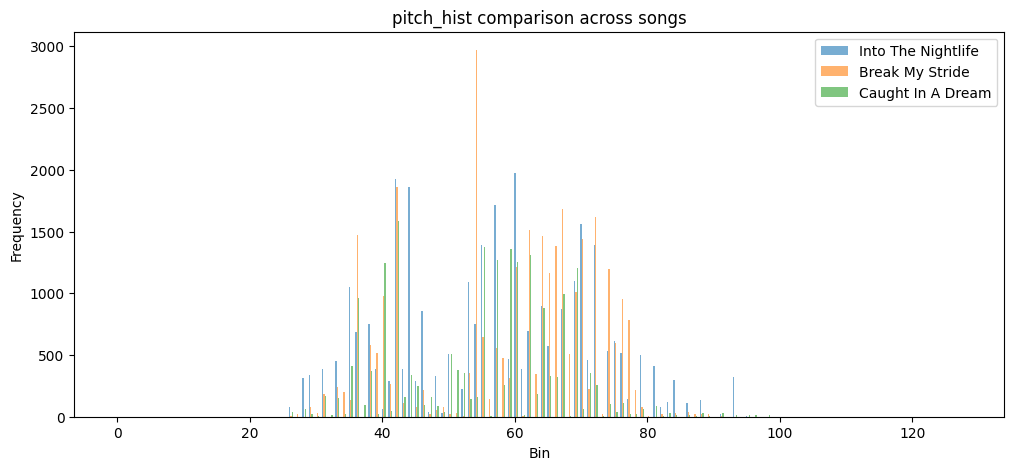

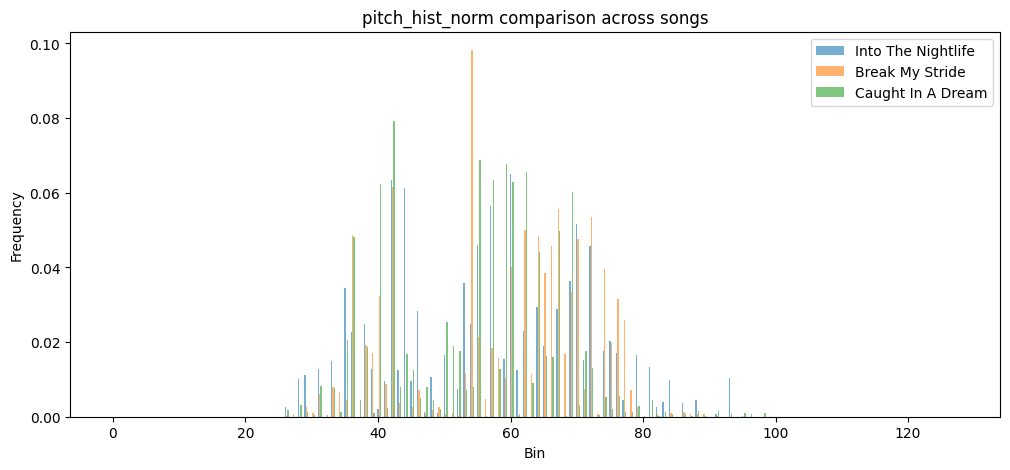

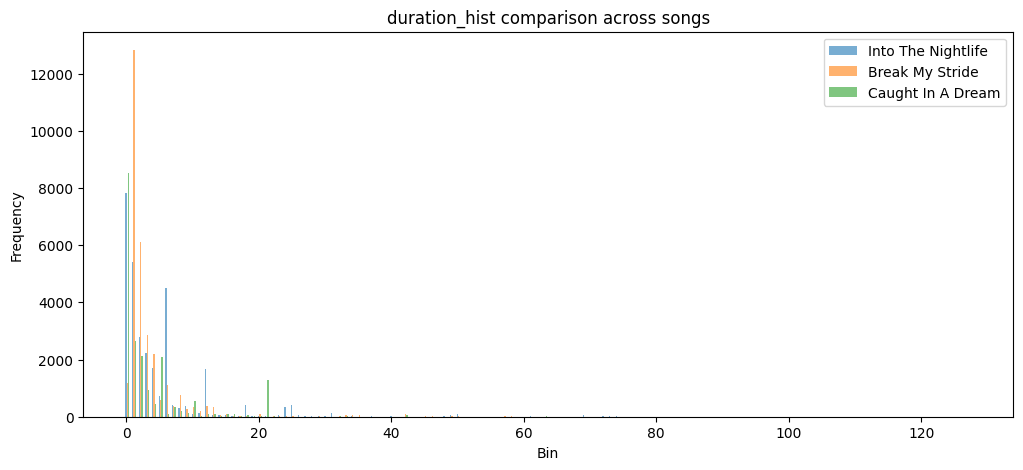

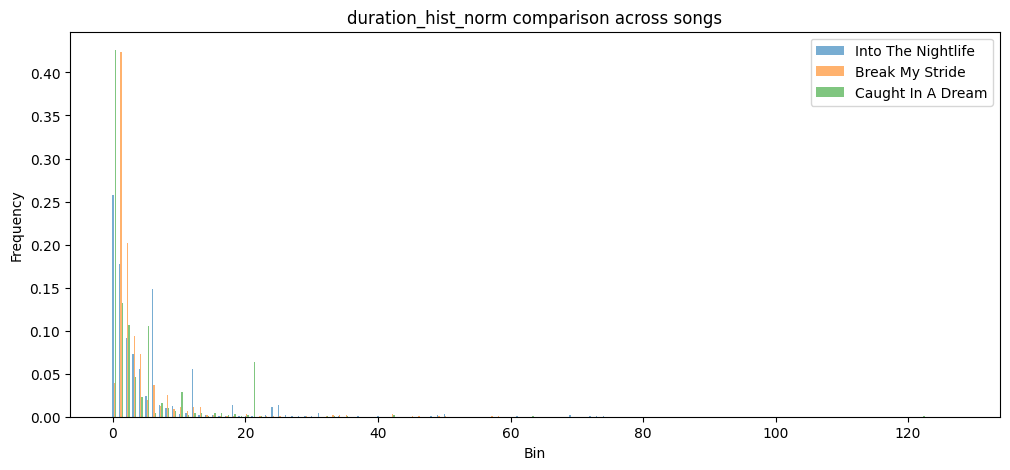

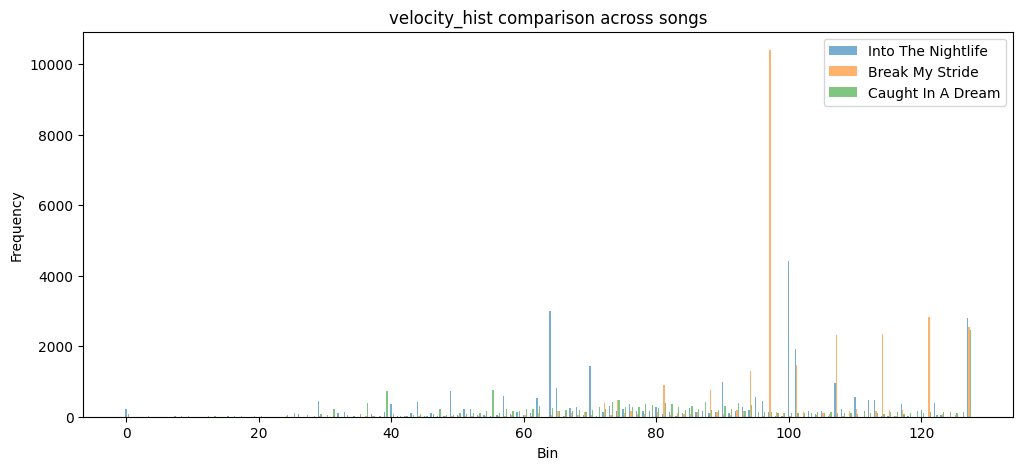

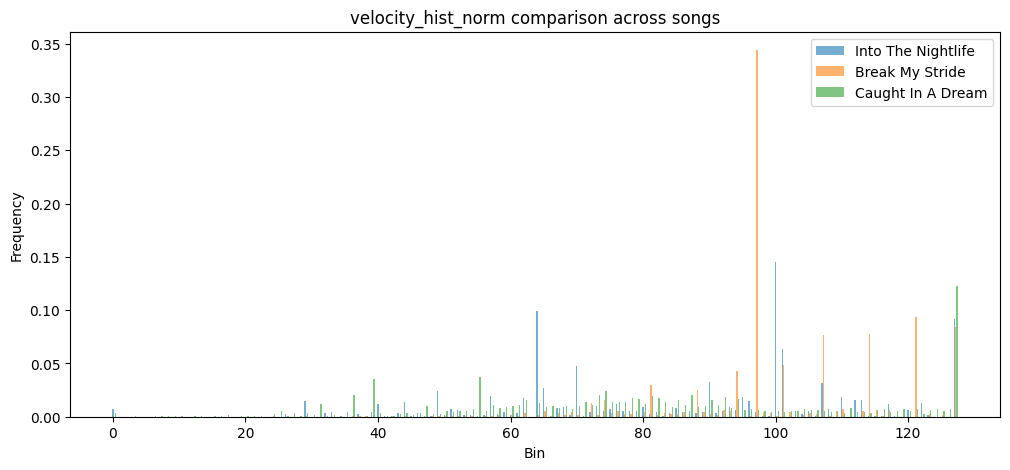

In [90]:
for col in feature_distributions_df.columns:
    if col not in ["track_id", "artist", "title", "path"]:

        plt.figure(figsize=(12, 5))

        x = None

        for i, row in enumerate(feature_distributions_df.itertuples()):
            if i >= 3:  # limit to first 3 songs for clarity
                break
            values = np.array(getattr(row, col))

            if x is None:
                x = np.arange(len(values))

            plt.bar(
                x + i * 0.2,   # small offset so bars don't overlap
                values,
                width=0.2,
                alpha=0.6,
                label=row.title
            )

        plt.title(f"{col} comparison across songs")
        plt.xlabel("Bin")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

COMMENT ON GRAPHS AND WHAT NEXT: